# Prediksi Usia Abalone dari Pengukuran Fisik

## Data Understanding


### Sumber dataset

https://archive.ics.uci.edu/dataset/1/abalone

Nash, W., Sellers, T., Talbot, S., Cawthorn, A., & Ford, W. (1994). Abalone [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55C7W.

### Penjelasan Fitur dan Variabel

Dataset ini adalah untuk memprediksi usia abalon dari pengukuran fisik. Usia abalon ditentukan dengan memotong cangkang melalui kerucut, menodainya, dan menghitung jumlah cincin melalui mikroskop - tugas yang membosankan dan memakan waktu.  Pengukuran lain, yang lebih mudah diperoleh, digunakan untuk memprediksi usia.  Informasi lebih lanjut, seperti pola cuaca dan lokasi (sehingga ketersediaan makanan) mungkin diperlukan untuk memecahkan masalah.

Dari contoh data asli dengan nilai yang hilang telah dihapus (sebagian besar memiliki nilai prediksi yang hilang), dan rentang nilai kontinu telah diskalakan untuk digunakan dengan JST (dengan membaginya dengan 200).

Fitur-fitur yang digunakan antara lain

* Sex  
* Length  
* Diameter  
* Height  
* Whole_weight  
* Shucked_weight  
* Viscera_weight  
* Shell_weight  
* Rings

Translate:

* Jenis kelamin
* Panjang
* Diameter
* Tinggi
* Berat_utuh
* Berat_buah
* Berat Viscera
* Berat cangkang
* Cincin

### Eksplorasi data


Dataset ini kebetulan tidak ada outlier dan tidak ada missing value

### Visualisasi data

In [63]:
%pip install ucimlrepo

In [64]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
abalone = fetch_ucirepo(id=1)

# data (as pandas dataframes)
X = abalone.data.features
y = abalone.data.targets

# metadata
print(abalone.metadata)

# variable information
print(abalone.variables)


{'uci_id': 1, 'name': 'Abalone', 'repository_url': 'https://archive.ics.uci.edu/dataset/1/abalone', 'data_url': 'https://archive.ics.uci.edu/static/public/1/data.csv', 'abstract': 'Predict the age of abalone from physical measurements', 'area': 'Biology', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Tabular'], 'num_instances': 4177, 'num_features': 8, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': [], 'target_col': ['Rings'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1994, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C55C7W', 'creators': ['Warwick Nash', 'Tracy Sellers', 'Simon Talbot', 'Andrew Cawthorn', 'Wes Ford'], 'intro_paper': None, 'additional_info': {'summary': 'Predicting the age of abalone from physical measurements.  The age of abalone is determined by cutting the shell through the cone, staining it, and counting the number of rings through a microscope -- 

In [65]:
import pandas as pd

# Gabungkan fitur dan target
df_abalone = pd.concat([X, y], axis=1)

# Tampilkan seluruh baris (jika datasetnya kecil)
# Jika besar, batasi baris atau ubah opsi tampilan
print("Total baris dataset ini adalah =",len(df_abalone))
print("Visualisasi dataset abalone")
print(df_abalone.to_string(index=False))


Total baris dataset ini adalah = 4177
Visualisasi dataset abalone
Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  Shell_weight  Rings
  M   0.455     0.365   0.095        0.5140          0.2245          0.1010        0.1500     15
  M   0.350     0.265   0.090        0.2255          0.0995          0.0485        0.0700      7
  F   0.530     0.420   0.135        0.6770          0.2565          0.1415        0.2100      9
  M   0.440     0.365   0.125        0.5160          0.2155          0.1140        0.1550     10
  I   0.330     0.255   0.080        0.2050          0.0895          0.0395        0.0550      7
  I   0.425     0.300   0.095        0.3515          0.1410          0.0775        0.1200      8
  F   0.530     0.415   0.150        0.7775          0.2370          0.1415        0.3300     20
  F   0.545     0.425   0.125        0.7680          0.2940          0.1495        0.2600     16
  M   0.475     0.370   0.125        0.5095          0.2165  

In [66]:
# Simpan ke file CSV
df_abalone.to_csv('datasetabalone.csv', index=False)

## Preprocessing Data

### Transformasi data

Target yang sebelumnya berisi numerik diubah ke kategorikal, antara lain Muda, Dewasa, Tua

In [67]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# === 1. Load Dataset ===
df = pd.read_csv('/content/datasetabalone.csv')

# === 2. Ubah Target jadi Kategori Usia ===
def label_usia(rings):
    if rings <= 8:
        return 'Muda'
    elif rings <= 11:
        return 'Dewasa'
    else:
        return 'Tua'

df['UsiaKategori'] = df['Rings'].apply(label_usia)

### Normalisasi data

Dataset dinormalisasi menggunakan StandarScaler dari library sklearn

In [68]:
# === 3. Encode Fitur Kategori "Sex" ===
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])  # M=1, F=0, I=2 (urutan bisa berbeda tergantung dataset)

# === 4. Pisahkan Fitur dan Label ===
X = df.drop(columns=['Rings', 'UsiaKategori'])  # fitur
y = df['UsiaKategori']                          # label klasifikasi

# === 5. Scaling (Opsional tapi disarankan) ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Split data

Dataset dipisahkan menjadi 2 yaitu data testing 20% dan data traning 80%

In [69]:
# === 6. Split Data Training & Testing ===
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#### Visualisasi data setelah preprocessing

In [70]:
import pandas as pd

# Gabungkan fitur dan target
df_abalonecategorical = pd.concat([X, y], axis=1)

# Tampilkan seluruh baris (jika datasetnya kecil)
# Jika besar, batasi baris atau ubah opsi tampilan
print("Total baris dataset ini adalah =",len(df_abalone))
print("Visualisasi dataset abalone setelah target diubah menjadi kategorikal")
print(df_abalonecategorical.to_string(index=False))


Total baris dataset ini adalah = 4177
Visualisasi dataset abalone setelah target diubah menjadi kategorikal
 Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  Shell_weight UsiaKategori
   2   0.455     0.365   0.095        0.5140          0.2245          0.1010        0.1500          Tua
   2   0.350     0.265   0.090        0.2255          0.0995          0.0485        0.0700         Muda
   0   0.530     0.420   0.135        0.6770          0.2565          0.1415        0.2100       Dewasa
   2   0.440     0.365   0.125        0.5160          0.2155          0.1140        0.1550       Dewasa
   1   0.330     0.255   0.080        0.2050          0.0895          0.0395        0.0550         Muda
   1   0.425     0.300   0.095        0.3515          0.1410          0.0775        0.1200         Muda
   0   0.530     0.415   0.150        0.7775          0.2370          0.1415        0.3300          Tua
   0   0.545     0.425   0.125        0.7680          0.2940

In [71]:
# Simpan ke file CSV
df_abalonecategorical.to_csv('datasetabalonecategorical.csv', index=False)

## Modelling

Modeling merupakan proses pembuatan dan pengujian model statistik atau matematis yang digunakan untuk menggambarkan dan menganalisis pola atau hubungan dalam data. Tujuan utama dari pemodelan dalam data mining adalah untuk mengidentifikasi pola yang berguna atau prediksi yang akurat dari data yang tersedia.

### Modelling Klasifikasi Dataset Abalone menggunakan Decision Tree

Pemodelan ini bertujuan untuk mengklasifikasikan usia seekor abalone berdasarkan sejumlah fitur fisik seperti panjang tubuh, diameter, berat total, dan atribut lainnya. Kategori usia yang digunakan dalam model ini terdiri dari tiga kelas, yaitu: Muda, Dewasa, dan Tua.

Model klasifikasi yang digunakan adalah Decision Tree Classifier, salah satu metode supervised learning yang berbasis aturan dan struktur pohon bercabang. Setiap cabang pada pohon merepresentasikan keputusan berdasarkan nilai fitur, dan setiap daun pada pohon menunjukkan hasil klasifikasi.

1. Pembagian Dataset: Data Latih dan Data Uji

Langkah pertama dalam pemodelan adalah membagi data menjadi:

* Data Latih (Training Set): untuk melatih model.
* Data Uji (Testing Set): untuk mengevaluasi performa model terhadap data baru yang belum pernah dilihat sebelumnya.

Dua rasio umum yang sering digunakan:

* 80% data latih dan 20% data uji
* 70% data latih dan 30% data uji

Untuk eksperimen ini, digunakan rasio 80:20, namun pemilihan rasio dapat disesuaikan berdasarkan kebutuhan dan kondisi data.

2. Pra-Pemrosesan Data

Sebelum data dimasukkan ke dalam model Decision Tree, beberapa tahapan pra-pemrosesan dilakukan:

* Kolom `Rings` (jumlah cincin) dikonversi menjadi kelas usia menggunakan aturan:

  * `Rings ≤ 8` → Muda
  * `9 ≤ Rings ≤ 11` → Dewasa
  * `Rings ≥ 12` → Tua
* Fitur `Sex` dikodekan menggunakan Label Encoding untuk mengubah kategori `['M', 'F', 'I']` menjadi nilai numerik `[0, 1, 2]`.
* Fitur-fitur lain seperti panjang dan berat tubuh tidak perlu diskritisasi karena Decision Tree mampu menangani data numerik secara langsung.

3. Pelatihan Model Decision Tree

Model dilatih dengan menggunakan algoritma Decision Tree, di mana:

* Setiap node pohon akan memecah data berdasarkan fitur yang paling mengurangi impurity (biasanya diukur dengan Gini Index atau Entropy).
* Pemisahan dilakukan secara rekursif hingga mencapai kedalaman tertentu (`max_depth`) atau data tidak dapat dipisah lebih lanjut.

Misalnya, pada model ini digunakan:

* Kriteria: `gini` (untuk mengukur kualitas split)
* Kedalaman maksimum: `5` (agar pohon tidak overfitting)

4. Evaluasi Model

Setelah model dilatih, langkah selanjutnya adalah mengevaluasi performa menggunakan:

* Akurasi: persentase prediksi yang benar terhadap total data uji.
* Classification Report: metrik evaluasi lainnya seperti precision, recall, dan F1-score untuk masing-masing kelas usia.
* Confusion Matrix: untuk melihat distribusi prediksi model terhadap kelas aktual.

Visualisasi pohon keputusan juga dapat ditampilkan untuk memahami struktur pengambilan keputusan oleh model — fitur mana yang paling penting, urutan pengujian fitur, dan bagaimana data diklasifikasikan di tiap cabang.

5. Prediksi Usia Abalone

Setelah pelatihan dan evaluasi, model siap digunakan untuk:

* Memprediksi kategori usia abalone baru berdasarkan nilai-nilai fitur fisiknya.
* Memahami fitur mana yang paling berpengaruh dalam menentukan usia (misalnya `Length`, `ShellWeight`, dll.)

Kesimpulan

Decision Tree adalah metode klasifikasi yang sangat cocok digunakan untuk dataset seperti Abalone karena:

* Mampu menangani fitur numerik tanpa perlu normalisasi.
* Dapat memberikan interpretasi visual melalui struktur pohon.
* Fleksibel dan cepat untuk dataset berukuran sedang.

Model ini dapat digunakan sebagai alat bantu prediksi usia abalone secara efisien, tanpa perlu menghitung cincin cangkang secara manual, yang biasanya lebih rumit dan memakan waktu.



Akurasi: 0.6674641148325359

=== Classification Report ===
              precision    recall  f1-score   support

      Dewasa       0.62      0.75      0.68       374
        Muda       0.77      0.73      0.75       279
         Tua       0.63      0.40      0.49       183

    accuracy                           0.67       836
   macro avg       0.67      0.63      0.64       836
weighted avg       0.67      0.67      0.66       836



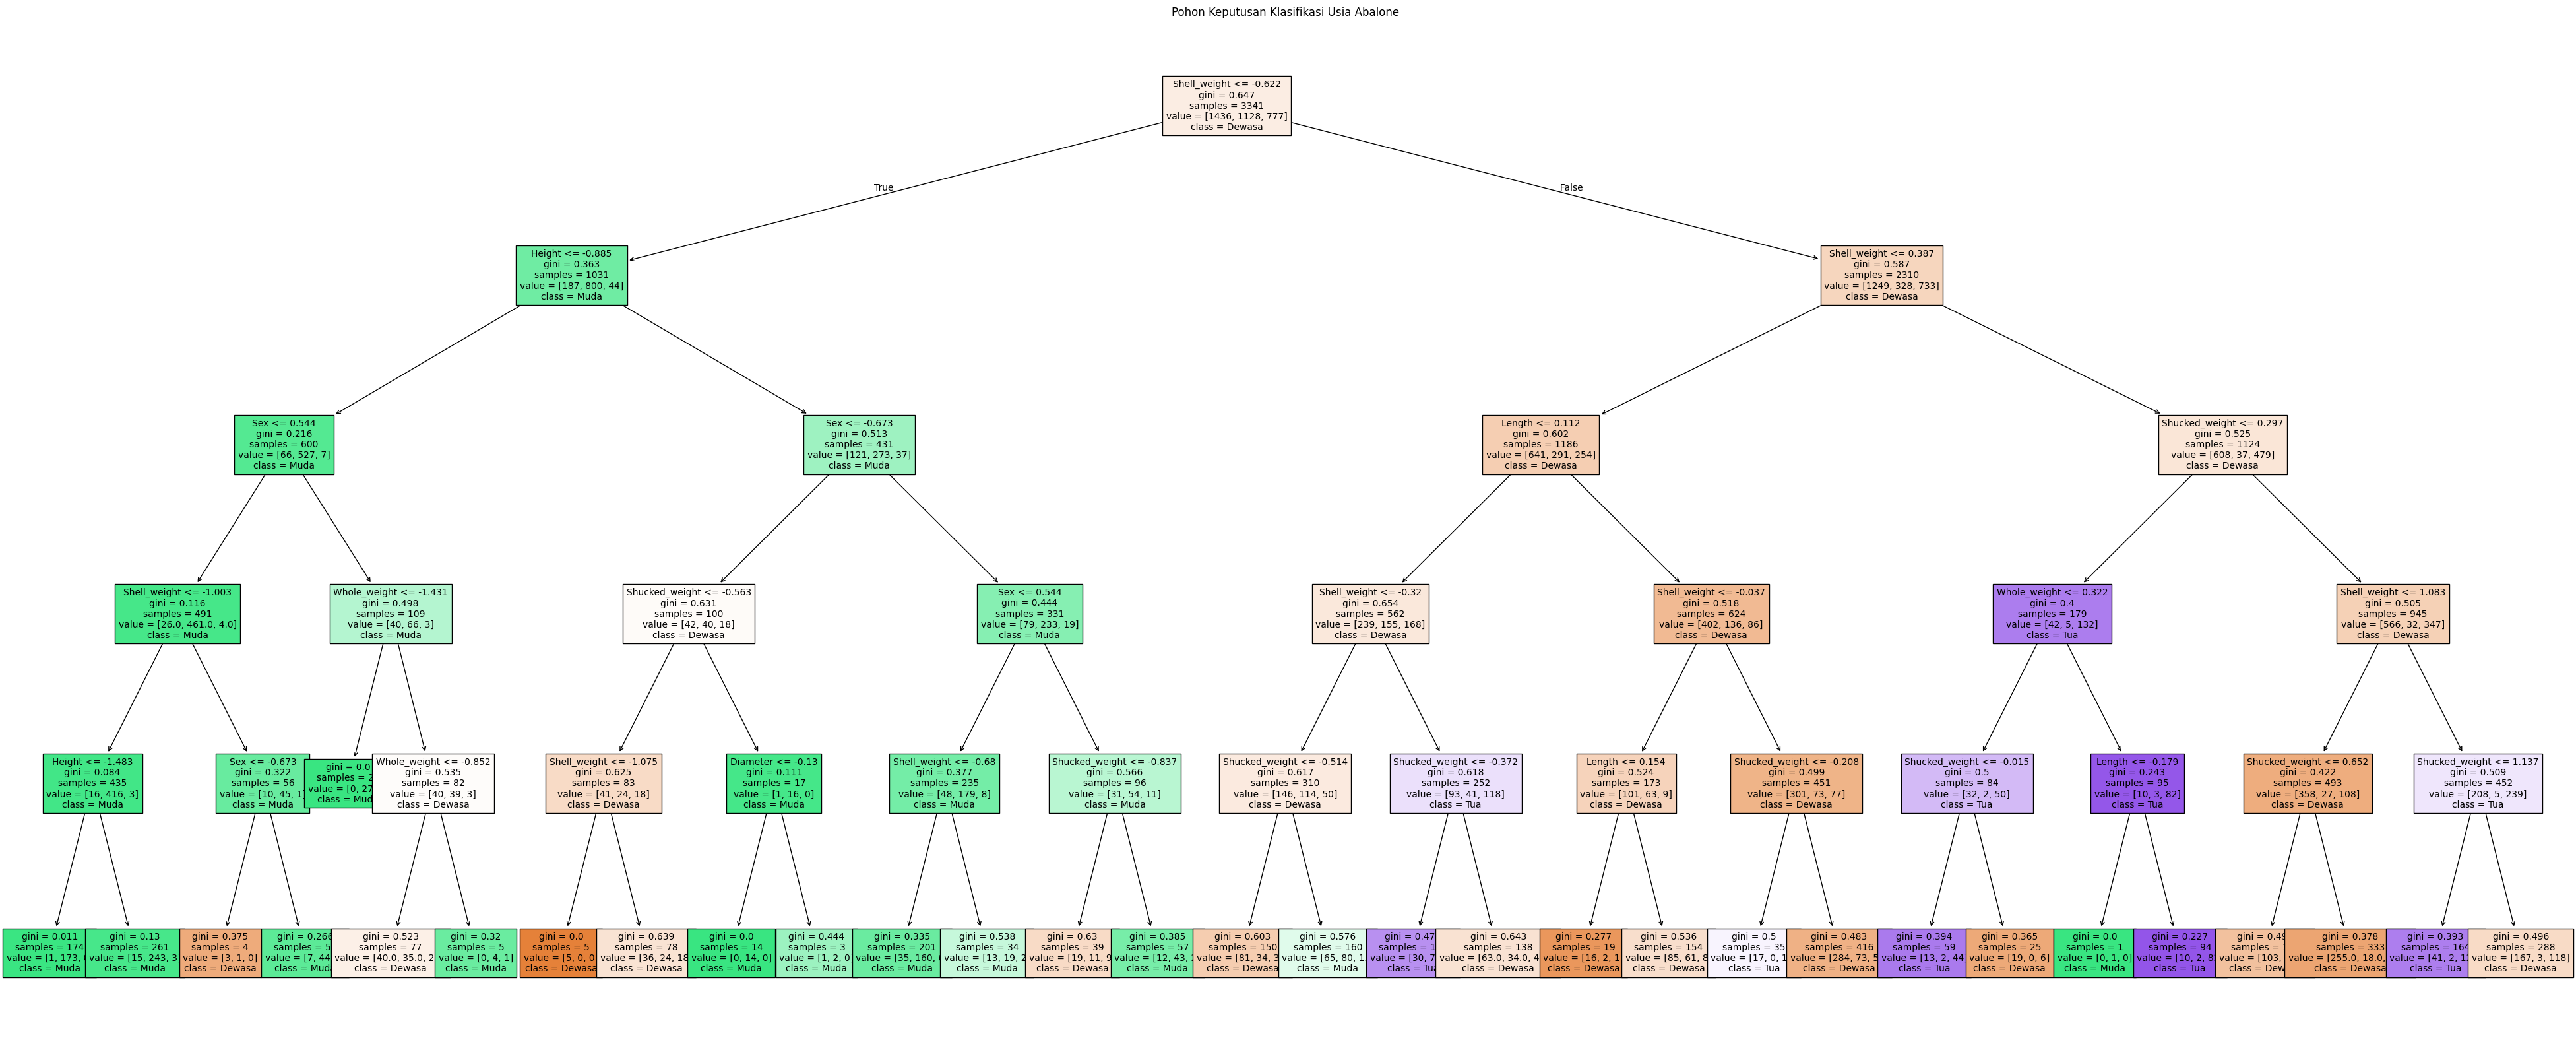

In [72]:

# === 7. Training Decision Tree ===
clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# === 8. Evaluasi Model ===
y_pred = clf.predict(X_test)
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# === 9. Visualisasi Struktur Pohon ===
plt.figure(figsize=(50, 20))
plot_tree(clf, feature_names=X.columns, class_names=clf.classes_, filled=True, fontsize=10)
plt.title("Pohon Keputusan Klasifikasi Usia Abalone")
plt.show()


### Modelling Klasifikasi Dataset Abalone menggunakan Gaussian Naive Bayes

Pada pemodelan kali ini, tujuan utama adalah untuk menentukan kelas usia dari seekor abalone berdasarkan fitur-fitur pengukuran fisik seperti panjang tubuh, berat cangkang, dan sebagainya. Kelas usia ini dibagi menjadi tiga kategori, yaitu: Muda, Dewasa, dan Tua.

Untuk membangun model klasifikasi ini, kita menggunakan metode Gaussian Naive Bayes (GNB), yang merupakan salah satu teknik pembelajaran mesin berbasis probabilistik.

1. Pembagian Dataset menjadi Data Latih dan Data Uji

Langkah awal dalam proses modelling adalah membagi data menjadi dua bagian:

* Data Latih (Train set) untuk membangun model.
* Data Uji (Test set) untuk mengukur performa model pada data yang belum pernah dilihat sebelumnya.

Umumnya, terdapat dua jenis pembagian rasio yang sering digunakan, yaitu:

* 80% data latih dan 20% data uji.
* 70% data latih dan 30% data uji.

Dalam modeling ini, kita memilih rasio 80:20, namun rasio ini dapat disesuaikan tergantung kondisi dan kebutuhan di lapangan.

2. Menghitung Probabilitas Awal (Prior Probability)

Setelah data terbagi, kita hitung probabilitas awal (prior) untuk masing-masing kelas usia. Caranya adalah:

* Hitung jumlah data latih untuk setiap kelas (`Muda`, `Dewasa`, `Tua`).
* Bagi dengan total jumlah data latih.

Nilai ini menunjukkan seberapa besar kemungkinan suatu abalone termasuk ke dalam kelas tersebut tanpa melihat fitur apapun.

3. Menghitung Rata-rata dan Standar Deviasi Tiap Fitur

Untuk setiap kelas usia, kita hitung:

* Rata-rata (mean) setiap fitur numerik seperti `Length`, `Diameter`, `Weight`, dll.
* Standar deviasi (standard deviation) untuk fitur-fitur tersebut.

Langkah ini penting karena GaussianNB mengasumsikan bahwa data dalam setiap fitur mengikuti distribusi normal (Gaussian).



4. Menghitung Distribusi Gaussian

Menggunakan rumus distribusi Gaussian, kita menghitung probabilitas kemunculan nilai fitur tertentu untuk setiap kelas usia.
Rumus distribusi Gaussian:

$$
P(x|\mu,\sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x - \mu)^2}{2\sigma^2} \right)
$$

dimana:

* $x$: nilai fitur input
* $\mu$: rata-rata fitur pada kelas tertentu
* $\sigma$: standar deviasi fitur pada kelas tertentu

5. Menghitung Posterior Probability

Setelah kita memperoleh probabilitas Gaussian dari masing-masing fitur, langkah selanjutnya adalah menghitung posterior dengan rumus:

$$
\text{Posterior} = P(x_1|C_i) \cdot P(x_2|C_i) \cdot \ldots \cdot P(x_n|C_i) \cdot P(C_i)
$$

dimana:

* $P(x_k|C_i)$: hasil distribusi Gaussian dari fitur ke-k pada kelas $C_i$
* $P(C_i)$: prior probability dari kelas $C_i$



6. Menentukan Prediksi Kelas

Langkah terakhir adalah membandingkan semua nilai posterior yang telah dihitung dari masing-masing kelas.

* Kelas dengan posterior terbesar adalah prediksi akhir untuk data input tersebut.

Berikut model yang telah dibuat untuk memprediksi usia abalone




Akurasi: 0.5633971291866029

=== Classification Report ===
              precision    recall  f1-score   support

      Dewasa       0.55      0.49      0.52       374
        Muda       0.67      0.80      0.73       279
         Tua       0.37      0.36      0.36       183

    accuracy                           0.56       836
   macro avg       0.53      0.55      0.54       836
weighted avg       0.55      0.56      0.56       836



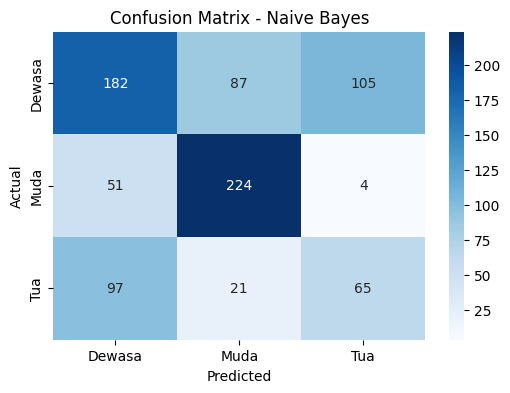

In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# === 7. Latih model Naive Bayes ===
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# === 8. Evaluasi hasil prediksi ===
y_pred = gnb.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# === 9. Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred, labels=gnb.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=gnb.classes_, yticklabels=gnb.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()


### Modelling Klasifikasi Dataset Abalone menggunakan K-Nearest Neighbor (K-NN)

Model K-Nearest Neighbors (KNN) digunakan dalam pemodelan ini untuk memprediksi kategori usia abalone: Muda, Dewasa, atau Tua, berdasarkan fitur-fitur fisik seperti panjang, diameter, berat tubuh, dan sebagainya.

KNN merupakan metode pembelajaran berbasis instance (instance-based learning), di mana prediksi kelas suatu data baru dilakukan dengan melihat “tetangganya” yang paling dekat dalam ruang fitur.

1. Pembagian Dataset: Training dan Testing

Seperti halnya metode supervised learning lainnya, dataset abalone terlebih dahulu dibagi menjadi dua bagian:

* Data Latih (Training Set): digunakan untuk menyimpan data referensi (tetangga).
* Data Uji (Testing Set): digunakan untuk menguji keakuratan model.

Dalam modeling ini, digunakan pembagian 80% data latih dan 20% data uji, yang merupakan praktik umum. Namun, pembagian ini bersifat fleksibel dan dapat disesuaikan tergantung kondisi data di lapangan.

2. Pra-Pemrosesan Data

Agar algoritma KNN bekerja optimal, beberapa tahapan pra-pemrosesan dilakukan:

* Konversi Target: Kolom `Rings` diklasifikasikan menjadi tiga kelas:

  * `Muda`: ≤ 8 cincin
  * `Dewasa`: 9–11 cincin
  * `Tua`: ≥ 12 cincin

* Encoding Fitur Kategorikal: Kolom `Sex` yang berisi nilai non-numerik (`M`, `F`, `I`) dikonversi menjadi numerik menggunakan Label Encoding.

* Scaling / Normalisasi: Fitur-fitur numerik seperti panjang, berat, dan diameter perlu dinormalisasi menggunakan metode seperti StandardScaler. Hal ini penting karena KNN sangat sensitif terhadap skala — fitur dengan nilai besar dapat mendominasi jarak jika tidak distandarkan.

3. Konsep Kerja KNN

Berbeda dengan model-model yang membentuk fungsi atau aturan eksplisit, KNN bekerja dengan menyimpan data latih dan menghitung jarak (biasanya Euclidean) antara data uji dan semua data latih.

Langkah-langkah:

1. Hitung jarak dari data uji ke semua data latih.
2. Ambil k data tetangga terdekat.
3. Lakukan voting — kelas usia yang paling sering muncul di antara tetangga tersebut akan menjadi prediksi akhir.

Misalnya:

* Jika `k = 5`, dan di antara 5 tetangga terdekat terdapat 3 yang berlabel "Dewasa", maka prediksi akhir adalah "Dewasa".

4. Evaluasi Model

Model KNN dievaluasi menggunakan:

* Akurasi: jumlah prediksi benar dibandingkan total data uji.
* Classification Report: mencakup precision, recall, dan F1-score untuk setiap kelas.
* Confusion Matrix: menunjukkan jumlah prediksi benar dan salah untuk masing-masing kelas.

Selain itu, eksperimen dengan nilai k yang berbeda (misalnya 3, 5, 7) juga dapat dilakukan untuk mencari k terbaik yang menghasilkan akurasi tertinggi.


Kesimpulan

Model K-Nearest Neighbors mampu melakukan klasifikasi usia abalone secara efektif dengan pendekatan berbasis kemiripan. Dengan syarat bahwa data telah melalui proses encoding dan normalisasi, KNN dapat menjadi solusi klasifikasi yang kuat, terutama ketika interpretabilitas sederhana dan kecepatan pengembangan model menjadi prioritas.

Model ini sangat bermanfaat untuk memprediksi usia abalone tanpa harus melakukan analisis cincin cangkang secara manual, yang biasanya memakan waktu dan keahlian khusus.

Akurasi: 0.6614832535885168

=== Classification Report ===
              precision    recall  f1-score   support

      Dewasa       0.62      0.70      0.66       374
        Muda       0.75      0.75      0.75       279
         Tua       0.60      0.45      0.51       183

    accuracy                           0.66       836
   macro avg       0.66      0.63      0.64       836
weighted avg       0.66      0.66      0.66       836



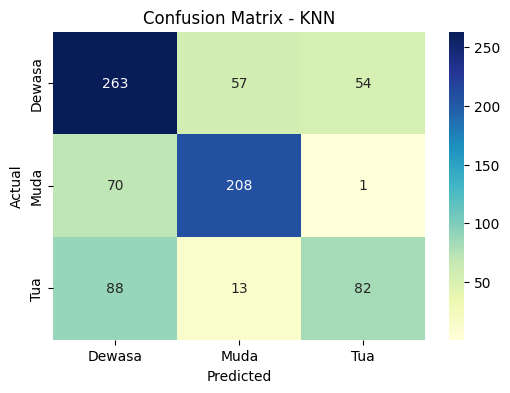

In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# === 7. Latih model KNN ===
knn = KNeighborsClassifier(n_neighbors=5)  # kamu bisa ubah k sesuai kebutuhan
knn.fit(X_train, y_train)

# === 8. Evaluasi ===
y_pred = knn.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# === 9. Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred, labels=knn.classes_)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=knn.classes_, yticklabels=knn.classes_, cmap='YlGnBu')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")
plt.show()


## Evaluasi Data

Dari dataset abalone diatas, akurasi yang didapatkan dari ketiga model klasifikasi antara lain:

* Decision Tree = 66,75%
* Gaussian Naive Bayes = 56,34%
* K-Nearest Neighbor = 66,15

Dari ketiga model diatas dapat disimpulkan bahwa Decision Tree memiliki akurasi tertinggi yaitu 66,75%.